In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

In [3]:
data = {
    'CustomerID': range(1, 11),
    'AnnualIncome': [15, 16, 17, 40, 42, 43, 60, 62, 63, 85],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 20, 95, 70, 5]
}

df = pd.DataFrame(data)
X = df[['AnnualIncome', 'SpendingScore']]

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters

In [5]:
sil_score = silhouette_score(X, clusters)
ch_score = calinski_harabasz_score(X, clusters)
db_score = davies_bouldin_score(X, clusters)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Score:", ch_score)
print("Davies-Bouldin Score:", db_score)

Silhouette Score: 0.4087094070941193
Calinski-Harabasz Score: 9.736895905261996
Davies-Bouldin Score: 0.7148546684457413


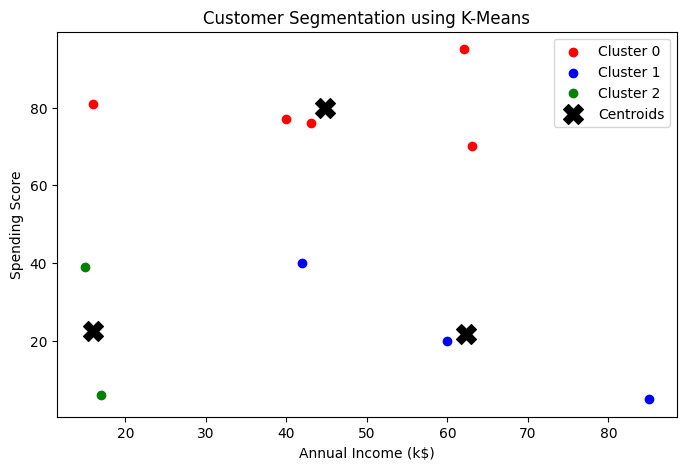

In [6]:
plt.figure(figsize=(8,5))
colors = ['red', 'blue', 'green']
for i in range(3):
    plt.scatter(
        df[df['Cluster']==i]['AnnualIncome'],
        df[df['Cluster']==i]['SpendingScore'],
        color=colors[i], label=f'Cluster {i}'
    )
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.show()

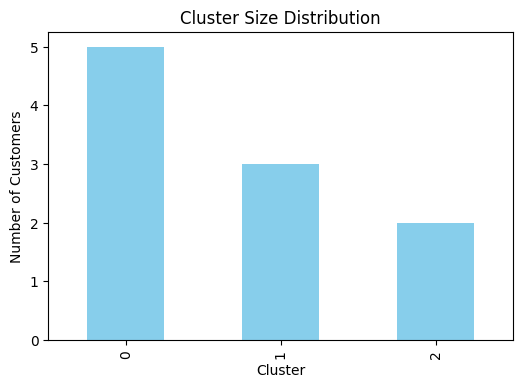

In [7]:
plt.figure(figsize=(6,4))
df['Cluster'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Size Distribution')
plt.show()